# Predict the electricity price

* Features:
    - electricy demand prediction
    - PV generation prediction
    - wind generation prediction
    - residual load (PV generation + wind generation - electricity demand)
*

In [1]:
# Set a consistent style for all plots
import matplotlib.pyplot as plt
plt.rcParams.update({
    'axes.grid':      True,
    'grid.color':     '#DCDCDC',
    'grid.linewidth': 0.5,
    'grid.linestyle': '-',
    'axes.axisbelow': True,
    'axes.facecolor': 'white',
    'font.family':    'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.titlepad':  13,
    'axes.labelsize': 10,
    'axes.labelpad':  8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'legend.frameon':    True,
    'legend.facecolor':  'white',
    'legend.edgecolor':  '#DCDCDC',
    'legend.framealpha': 1.0,
    'legend.fontsize':   9,
})

import sys
import os

# Add the src directory to the system path to allow importing custom modules
project_root = os.path.abspath("..")
src_dir = os.path.join(project_root, "src")
util_dir = os.path.join(project_root, "util")

if project_root not in sys.path:
    sys.path.insert(0, project_root)
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)
if util_dir not in sys.path:
    sys.path.insert(0, util_dir)


import warnings
warnings.filterwarnings('ignore')

# Enable autoreload to automatically reload modules when they are edited
%load_ext autoreload
%autoreload 2
    
from src.config import *
from util.weather_weighted import *
from src.etl_price import *
from src.fetch_price_data import *
from src.train_predict_model import *
from util.time_features import *

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path

#update_database()

# One-liner data preparation: loads, merges, engineers features, returns training-ready dataset 
df_price_model = prepare_price_model_dataset()

print("model rows:", len(df_price_model))
print("time range:", df_price_model["time"].min(), "->", df_price_model["time"].max())
print("feature count:", len(df_price_model.columns) - 2)  # Subtracting 'time' and target column
display(df_price_model.shape)

model rows: 64552
time range: 2019-01-15 00:00:00+00:00 -> 2026-05-27 21:00:00+00:00
feature count: 47


(64552, 49)

In [3]:
# Train-test split by date
split_date = pd.Timestamp("2025-10-01", tz="UTC")
price_features_train, price_target_train, price_features_test, price_target_test = train_test_split_by_date(
    df = df_price_model, date_column='time', target_column="price_de_lu_eur_mwh", split_date=split_date
)
print("Training set:", price_features_train.shape, price_target_train.shape)
print("Testing set:", price_features_test.shape, price_target_test.shape)

Training set: (58818, 47) (58818,)
Testing set: (5734, 47) (5734,)


In [29]:
# tune LightGBM model with Bayesian optimization
from lightgbm import LGBMRegressor
from skopt import BayesSearchCV

param_lgbm = {
    'n_estimators':  (50, 500),
    'learning_rate': (0.01, 0.3),
    'max_depth':     (3, 15),
}

start_time = pd.Timestamp.now()

model_lgbm = LGBMRegressor(random_state=42, force_col_wise=True)
price_model_lgbm, best_params_lgbm = tune_model_bayesian(
    model_pipeline=model_lgbm,
    in_param_bayes=param_lgbm,
    in_features_train=price_features_train,
    in_target_train=price_target_train,
)
print(f"Best hyperparameters: {best_params_lgbm}")
print()

pred_lgbm = price_model_lgbm.predict(price_features_test)
print_scores('LightGBM', price_target_test, pred_lgbm)

save_model_to_pickle(price_model_lgbm, '../models/price_lgbm_model.pkl')
print("Saved to: ../models/price_lgbm_model.pkl")

# training time
end_time = pd.Timestamp.now()
training_time = end_time - start_time
# show in minutes and seconds
minutes, seconds = divmod(training_time.total_seconds(), 60)
print(f"\nTraining time: {int(minutes)}'{int(seconds)}\"")

[LightGBM] [Info] Total Bins 10793
[LightGBM] [Info] Number of data points in the train set: 58818, number of used features: 47
[LightGBM] [Info] Start training from score 95.123176
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

In [30]:
# Tune the XGBoost model using the standardized feature set
from xgboost import XGBRegressor

param_xgb_continuous = {
    'n_estimators': (50, 1000),
    'max_depth': (3, 15),
    'learning_rate': (0.01, 0.3),
    'subsample': (0.5, 1.0),
    'colsample_bytree': (0.5, 1.0),
}

start_time = pd.Timestamp.now()

model_xgb = XGBRegressor(random_state=42)
price_model_xgb, price_best_params_xgb = tune_model_bayesian(
    model_pipeline=model_xgb,
    in_param_bayes=param_xgb_continuous,
    in_features_train=price_features_train,   
    in_target_train=price_target_train
)
print(f"Best hyperparameters for XGBoost: {price_best_params_xgb}")

y_pred_xgb = price_model_xgb.predict(price_features_test)
print_scores('XGBoost', price_target_test, y_pred_xgb)

save_model_to_pickle(price_model_xgb, '../models/price_xgb_model.pkl')

# training time
end_time = pd.Timestamp.now()
training_time = end_time - start_time
# show in minutes and seconds
minutes, seconds = divmod(training_time.total_seconds(), 60)
print(f"\nTraining time: {int(minutes)}'{int(seconds)}\"")

Best hyperparameters for XGBoost: OrderedDict({'colsample_bytree': 1.0, 'learning_rate': 0.08218260959163944, 'max_depth': 3, 'n_estimators': 1000, 'subsample': 0.5})
-------------------- scoring --------------------
model                  MAE       RMSE       R²
XGBoost               14.48      23.46     0.79

Training time: 10'13"


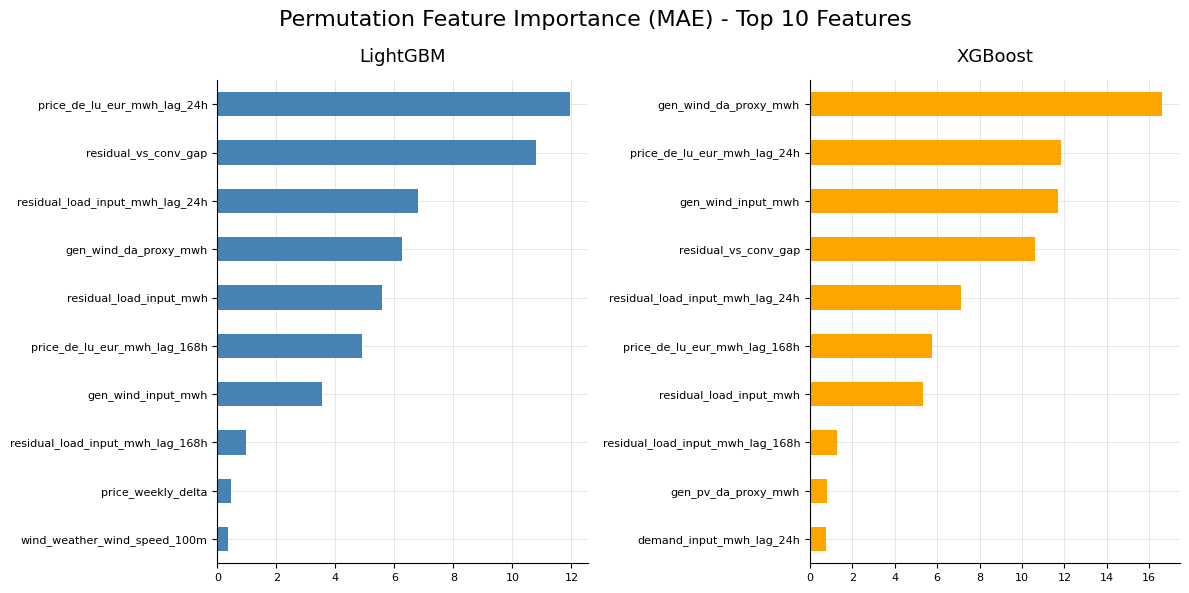

In [9]:
# plot permutation feature importance of three selected models for MAE
from sklearn.inspection import permutation_importance
from matplotlib import pyplot as plt

price_model_lgbm = load_model_from_pickle('../models/price_lgbm_model.pkl')
price_model_xgb = load_model_from_pickle('../models/price_xgb_model.pkl')

perm_importance_mae_lgbm = permutation_importance(price_model_lgbm, price_features_test, price_target_test, scoring='neg_mean_absolute_error')
perm_importances_mae_lgbm = pd.Series(perm_importance_mae_lgbm.importances_mean, index=price_model_lgbm.feature_name_).sort_values(ascending=True).tail(10)
perm_importance_mae_xgb = permutation_importance(price_model_xgb, price_features_test, price_target_test, scoring='neg_mean_absolute_error')
perm_importances_mae_xgb = pd.Series(perm_importance_mae_xgb.importances_mean, index=price_features_test.columns).sort_values(ascending=True).tail(10)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
perm_importances_mae_lgbm.plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title("LightGBM")
perm_importances_mae_xgb.plot.barh(ax=axes[1], color='orange')
axes[1].set_title("XGBoost")
fig.suptitle("Permutation Feature Importance (MAE) - Top 10 Features", fontsize=16)
plt.tight_layout()
plt.show()

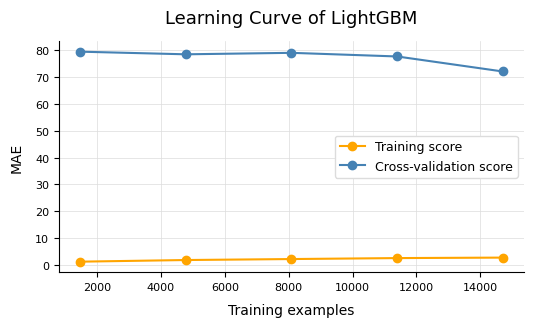

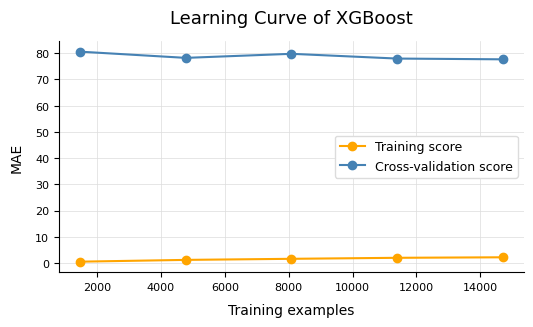

In [32]:
# learn curve for LightGBM and XGBoost model
plot_learning_curve(price_model_lgbm, 'LightGBM', price_features_train, price_target_train)
plot_learning_curve(price_model_xgb,  'XGBoost', price_features_train, price_target_train)
